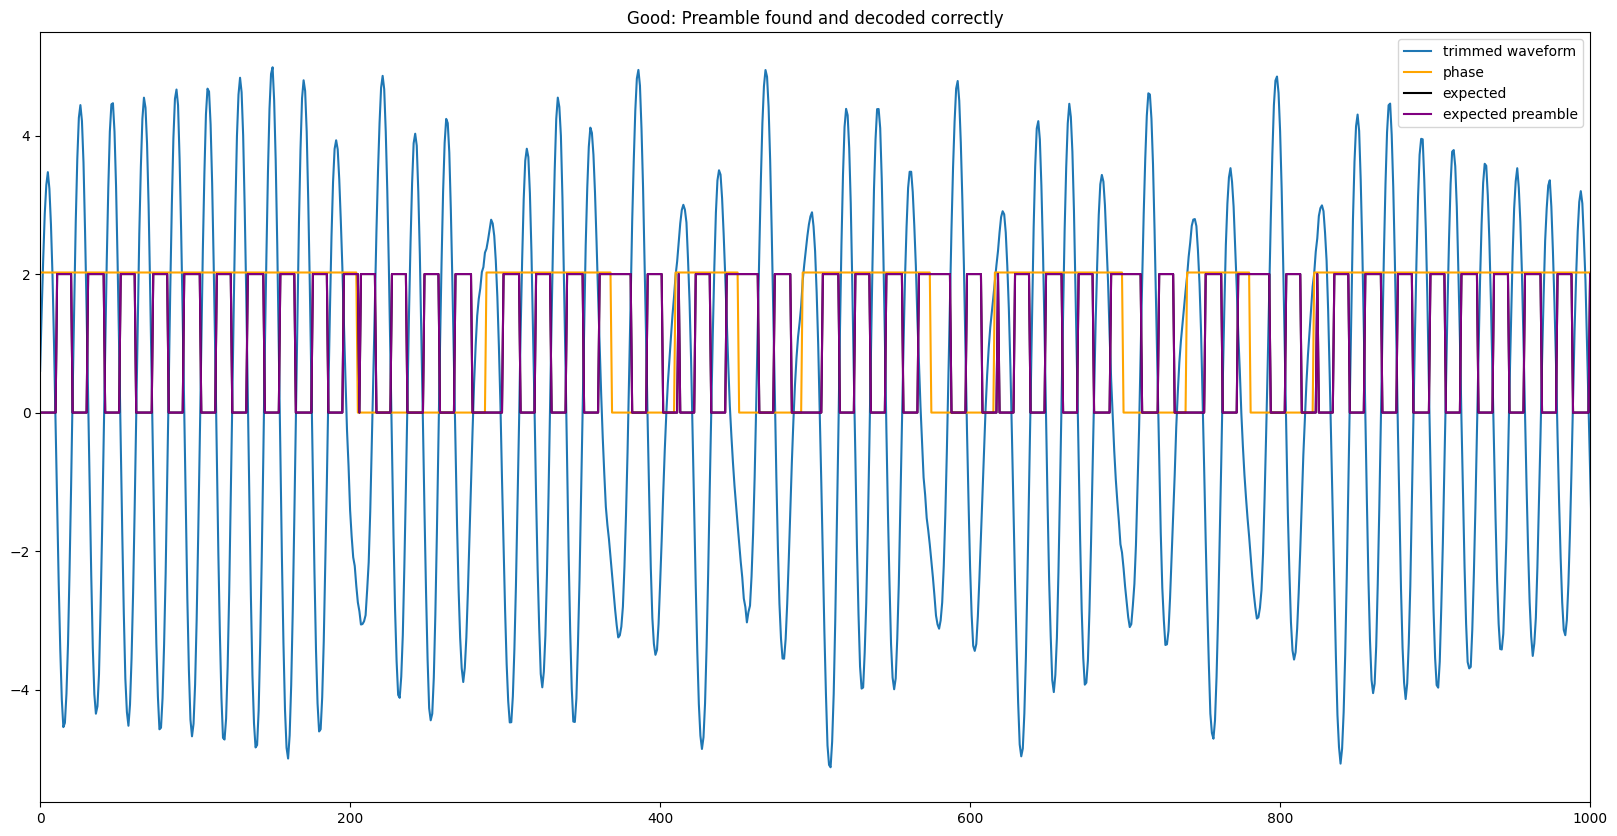

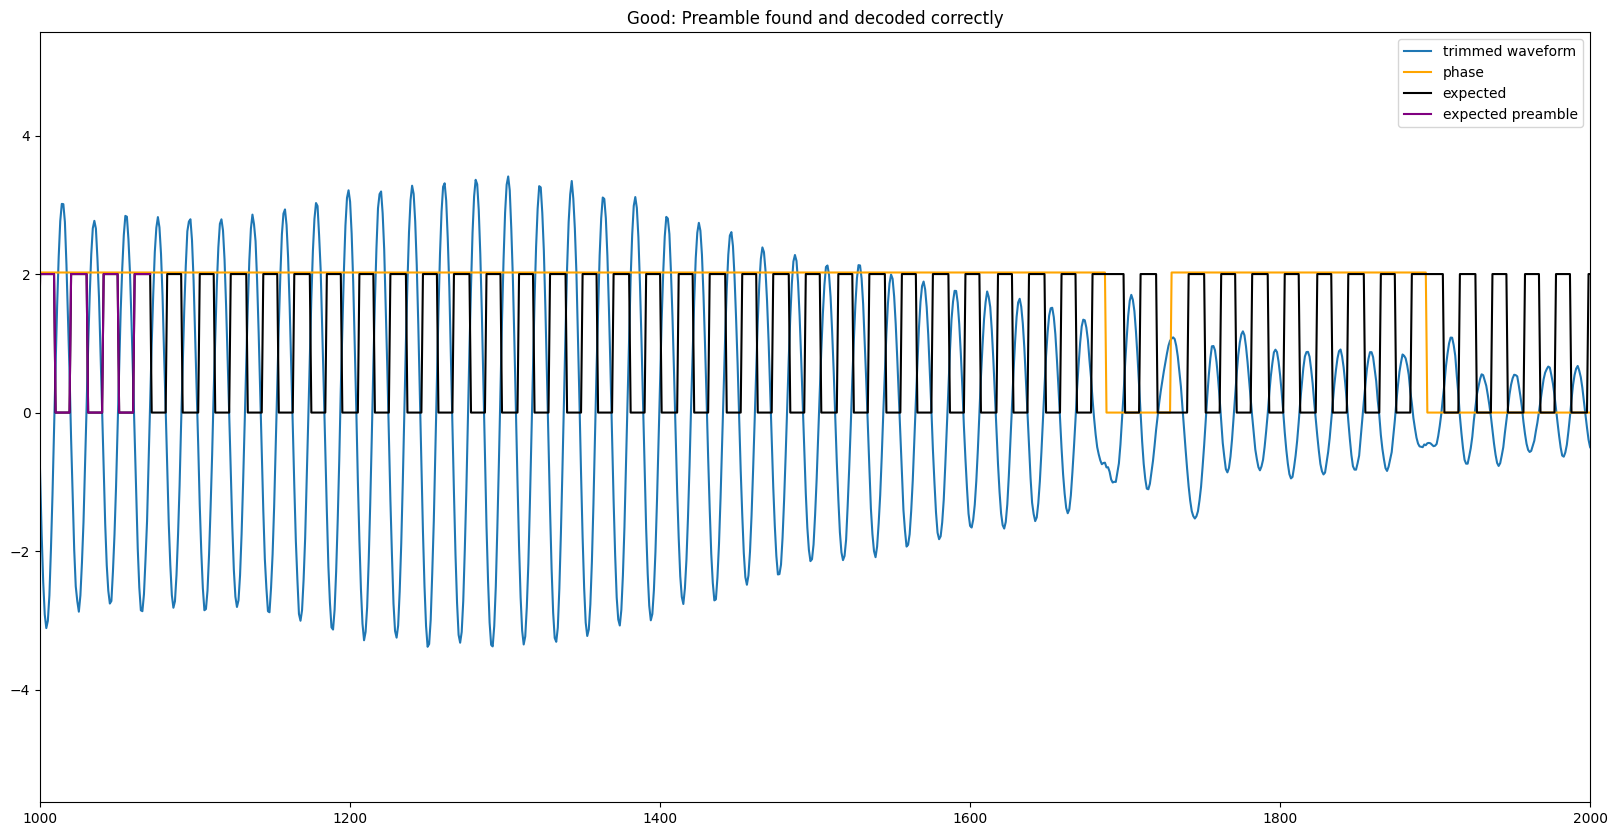

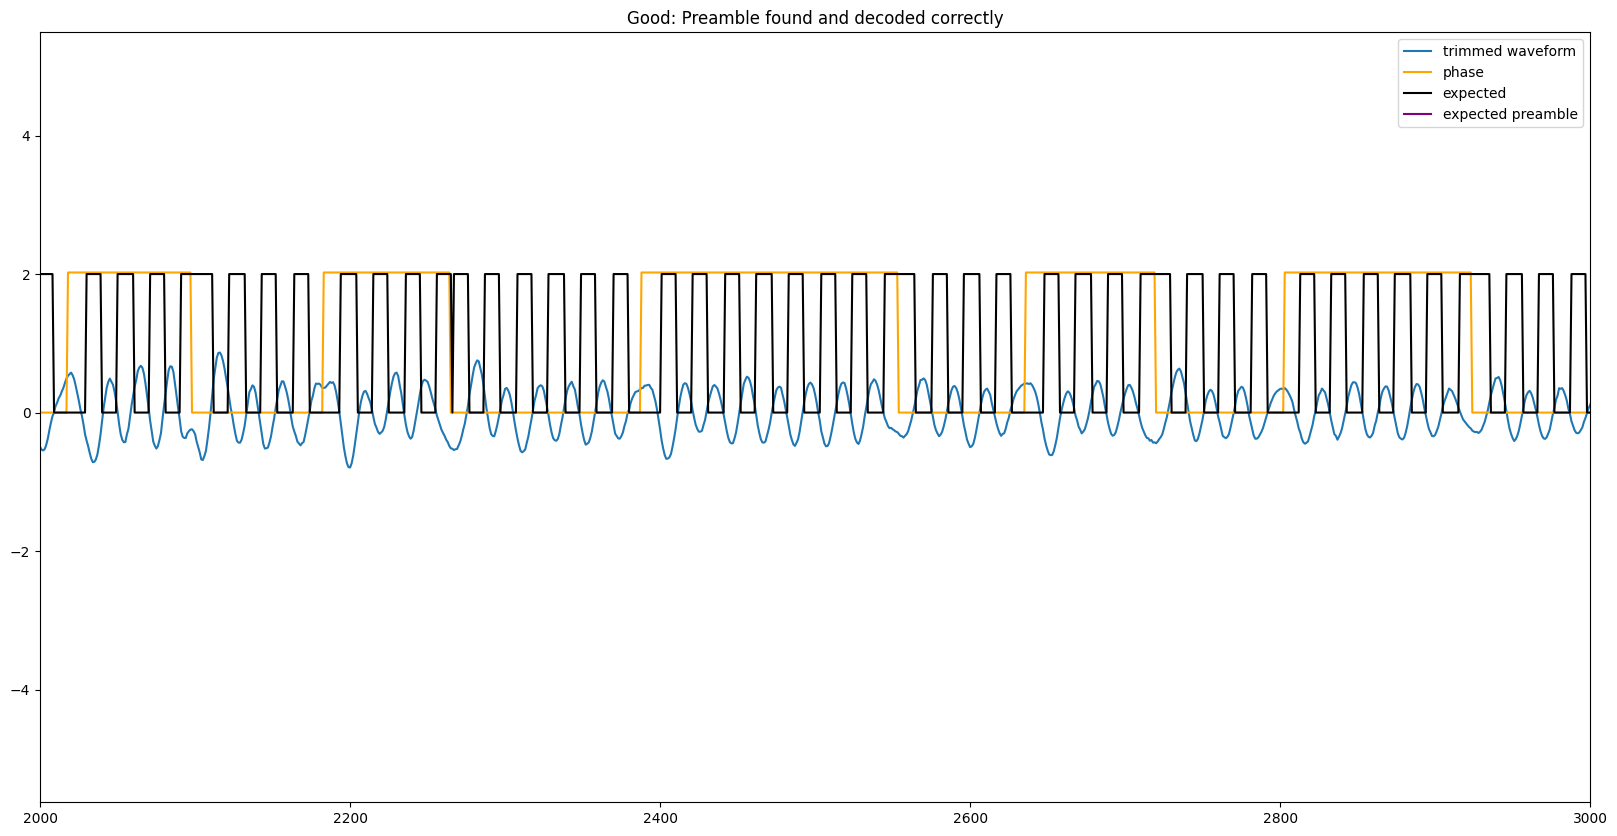

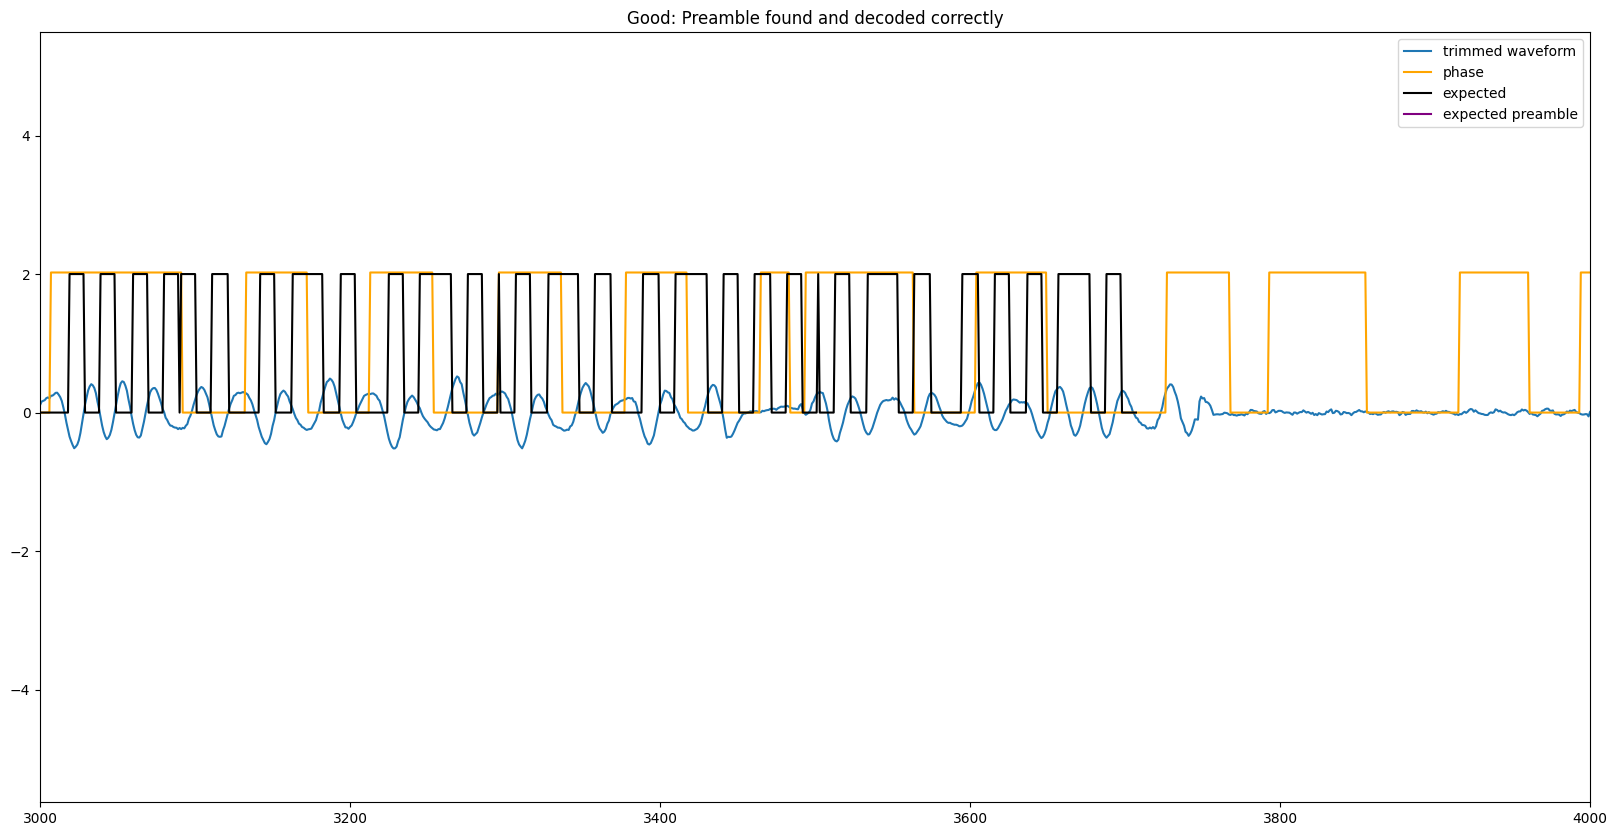

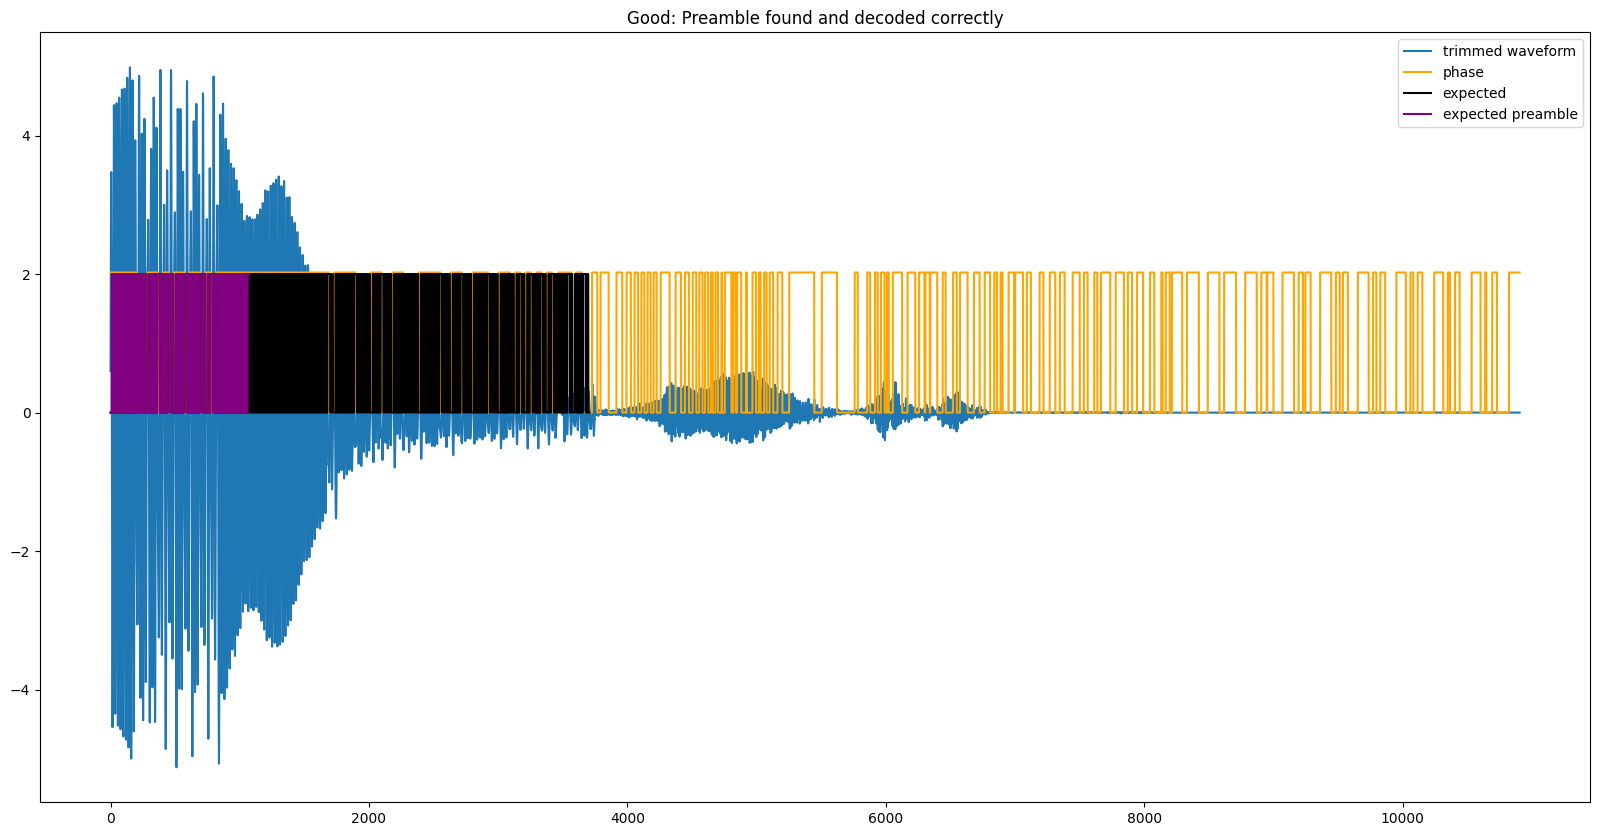

In [42]:
import matplotlib.pyplot as plt
import numpy as np


def plot_baseband(
    title: str,
    trimmed_waveform,
    phase,
    expected,
    samples_per_symbol,
    start: int = 0,
    end: int = 1000,
    save: bool = True,
    unlimited: bool = False,
):
    phase = np.angle(phase)
    expected = np.angle(expected)

    normalized_trimmed_waveform = trimmed_waveform / np.std(trimmed_waveform)
    normalized_phase = phase / np.std(phase)
    normalized_expected = expected / np.std(expected)

    # 13=barker code bits, 2=each symbol is repeated 2 times
    preamble_samples = samples_per_symbol * 13 * 2

    plt.figure(figsize=(20, 10))
    plt.title(title)
    plt.plot(normalized_trimmed_waveform[::10], label="trimmed waveform")
    plt.plot(normalized_phase[::10], label="phase", color="orange")
    plt.plot(normalized_expected[::10], label="expected", color="black")
    plt.plot(
        normalized_expected[:preamble_samples:10],
        label="expected preamble",
        color="purple",
    )

    if not unlimited:
        plt.xlim([start, end])
    plt.legend()
    if save:
        plt.savefig(f"../../output/{start}_{end}.png")


def print_everything(data, title: str, gap: int = 1000, max: int = 4000):
    trimmed_waveform = data["trimmed_waveform"]
    phase = data["phase"]
    expected = data["expected"]
    samples_per_symbol = data["samples_per_symbol"]
    for start in range(0, max, gap):
        end = start + gap
        plot_baseband(
            title,
            trimmed_waveform,
            phase,
            expected,
            samples_per_symbol,
            start,
            end,
            False,
        )
    plot_baseband(
        title,
        trimmed_waveform,
        phase,
        expected,
        samples_per_symbol,
        unlimited=True,
        save=False,
    )


data = np.load("../../output/drift_data_good.npz")
print_everything(data, "Good: Preamble found and decoded correctly")

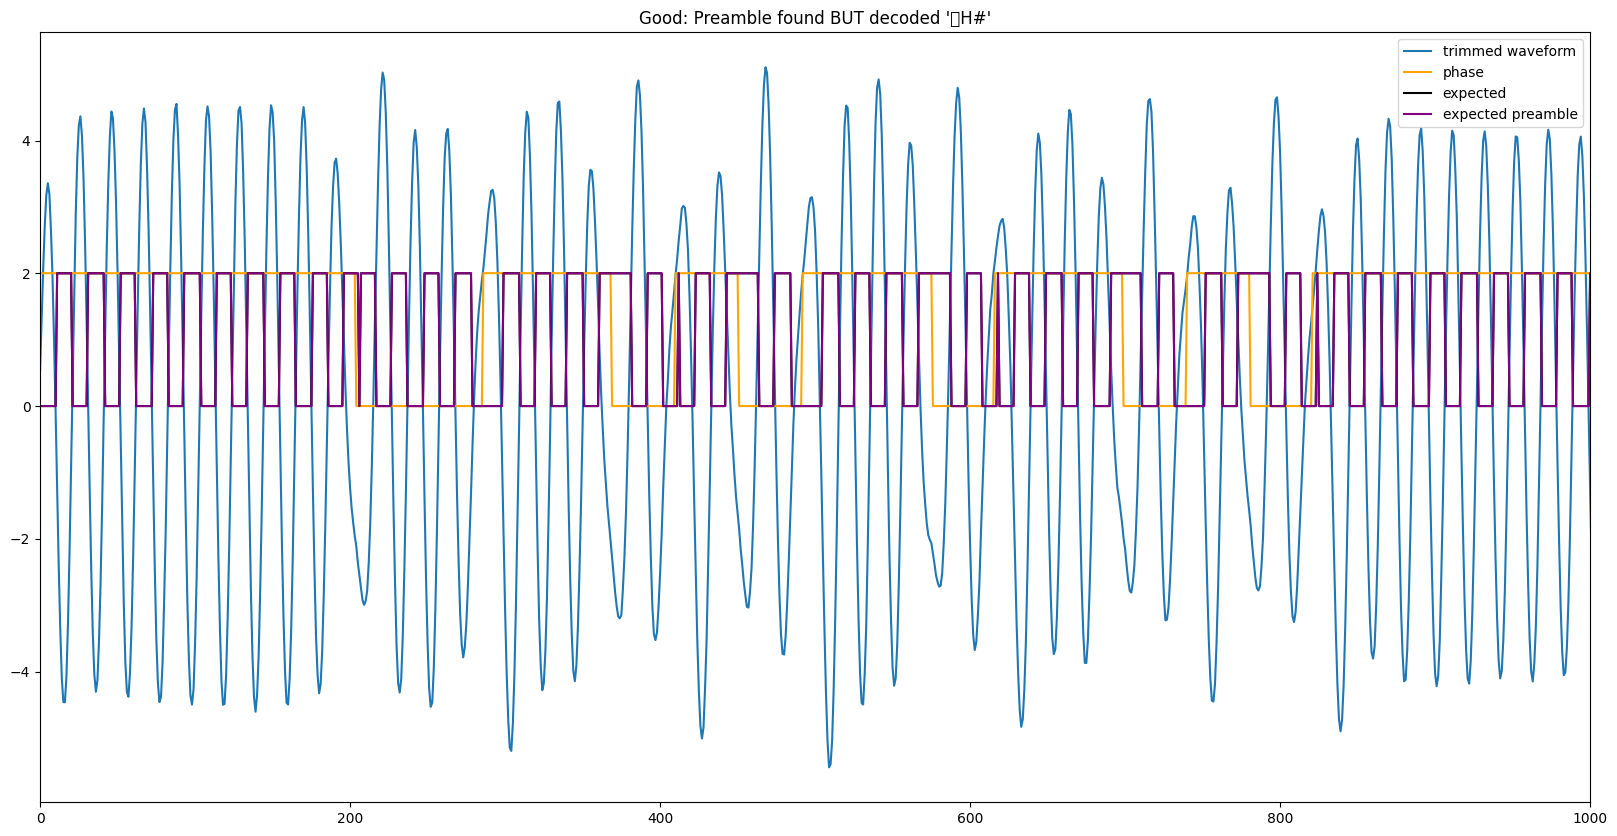

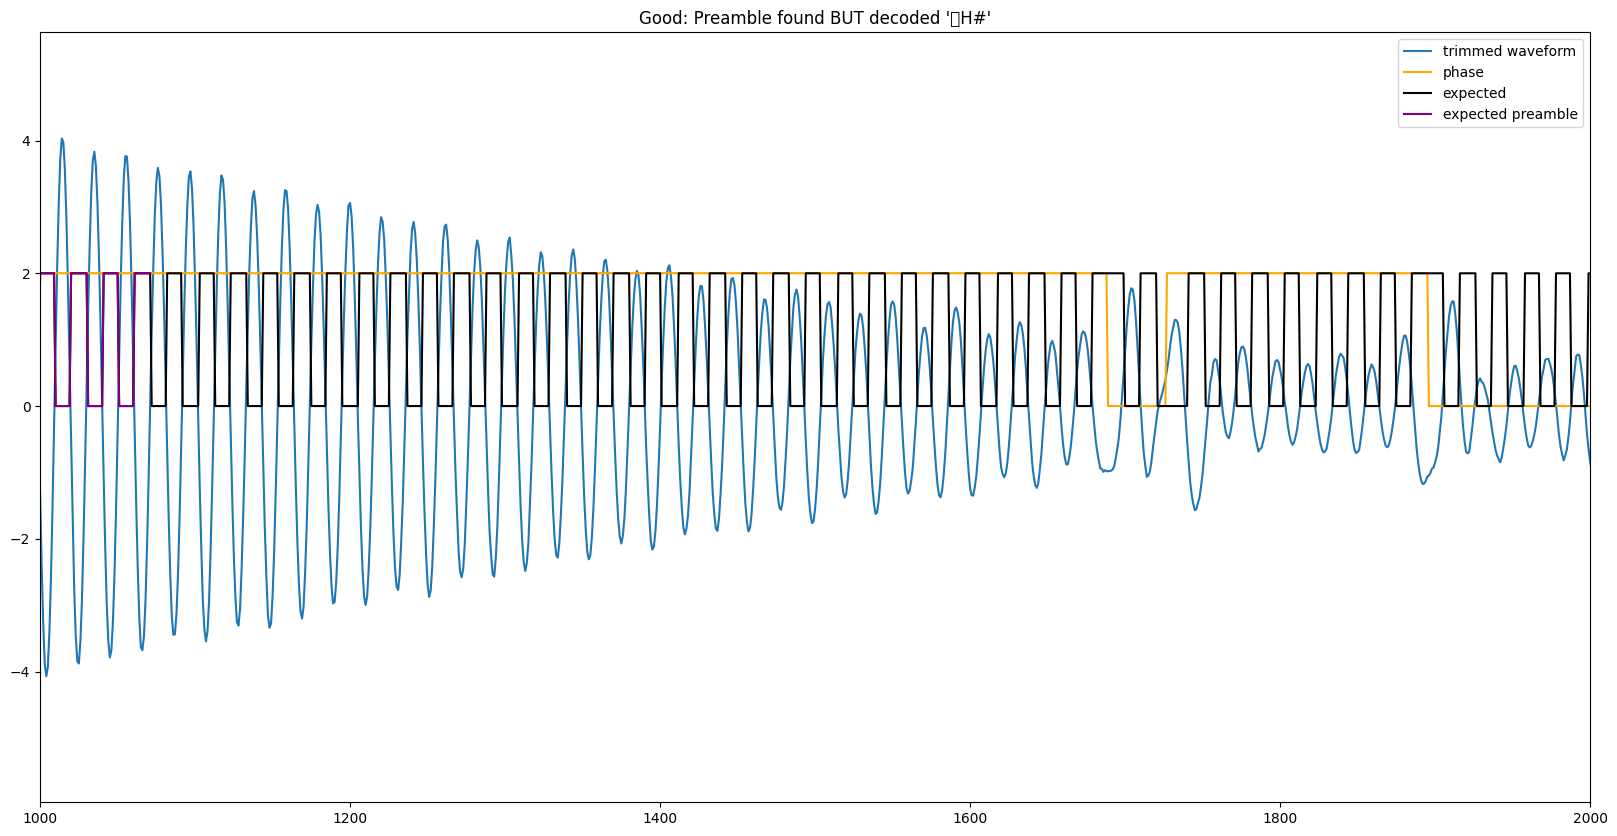

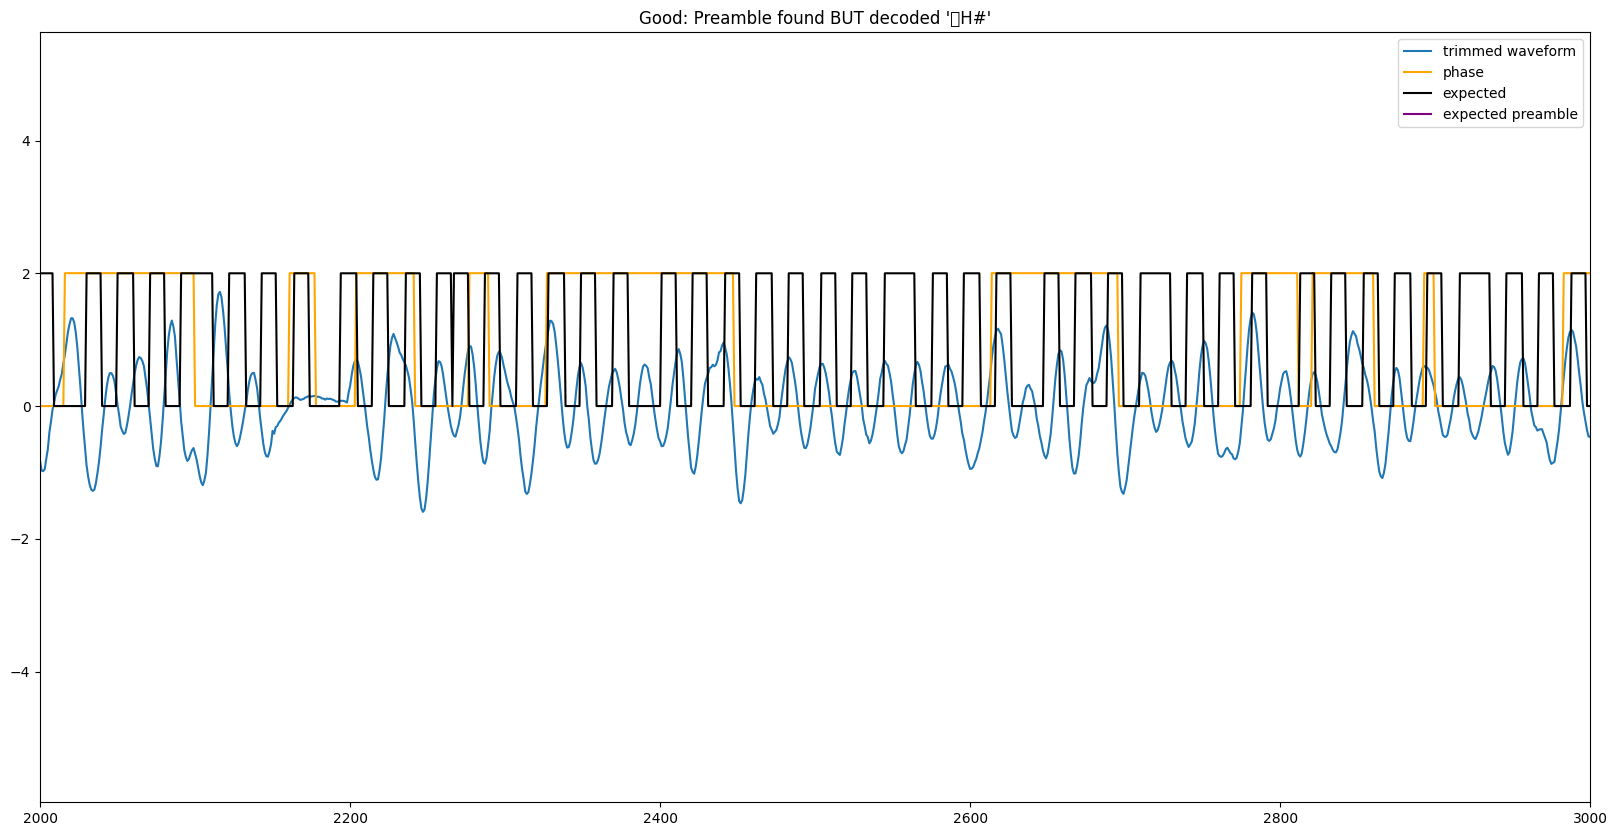

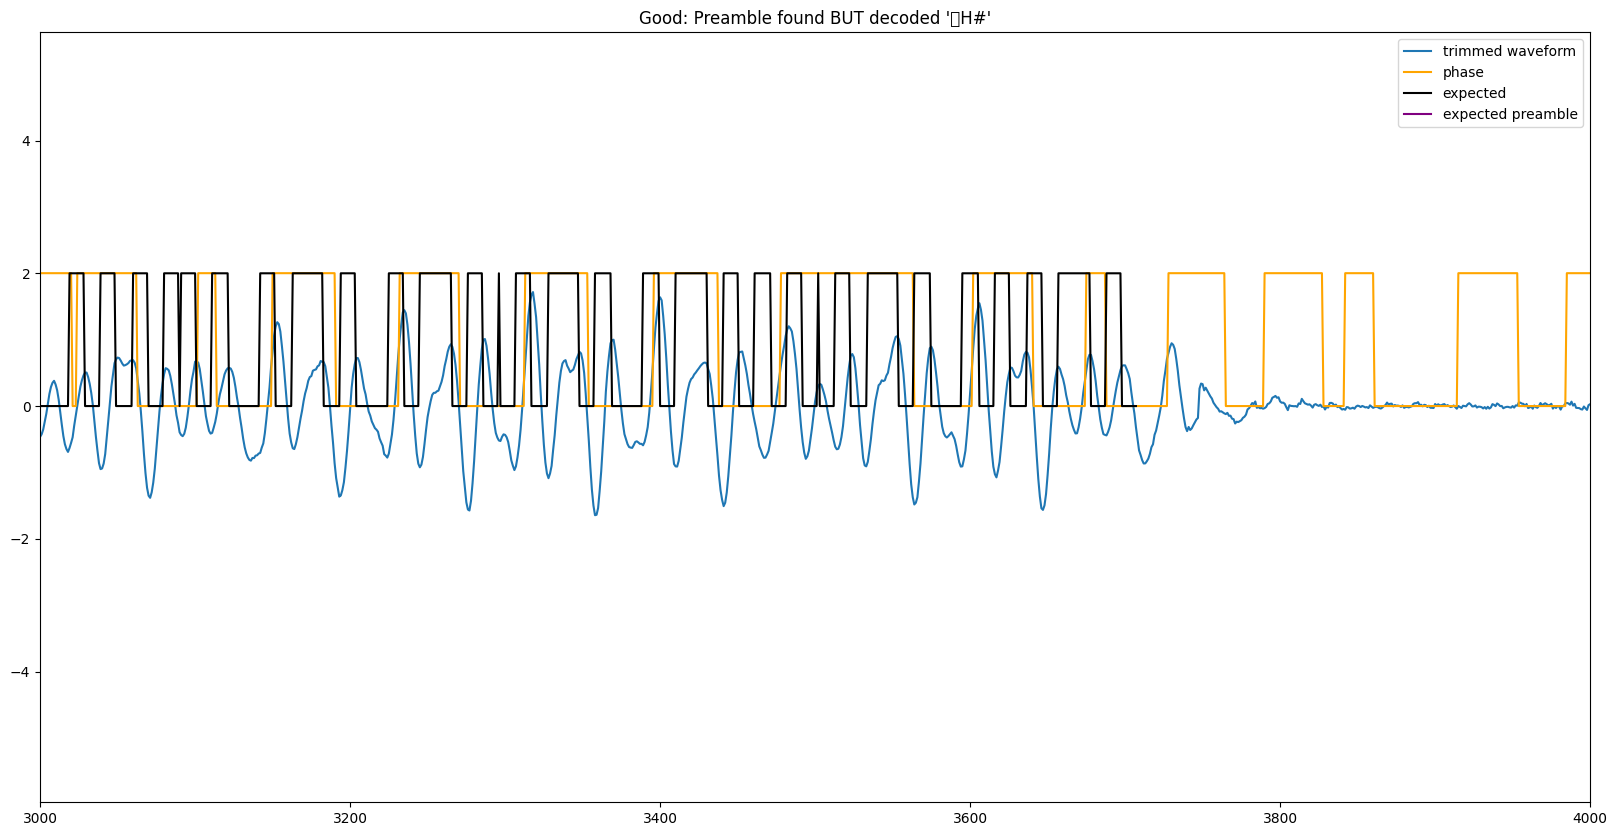

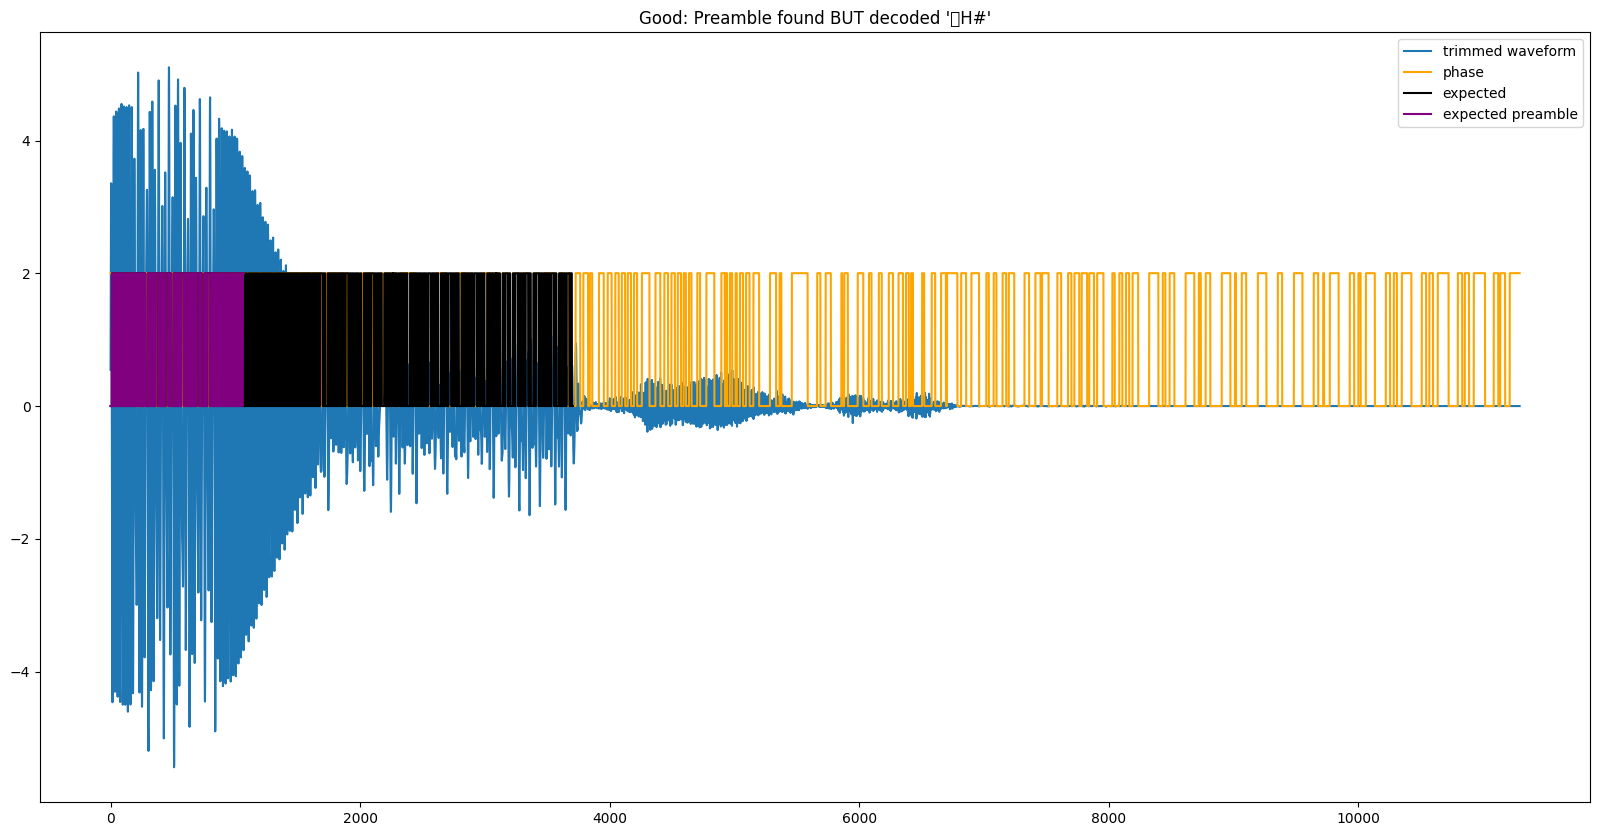

In [43]:
data = np.load("../../output/drift_data_bad.npz")
print_everything(data, "Good: Preamble found BUT decoded '\x17H#'")